In [96]:
#Importing all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

In [97]:
#Loading the dataset
dataset = load_from_disk("dataset")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})


In [ ]:
#preparing training data

In [98]:
#obtaining training data from the dataset
train = dataset['train']

In [99]:
#creating empty lists for images and labels
images = []
labels = []

In [100]:
#looping through the data and inserting the image and label
for data in train:
    #converting the image to numpy array
    img = np.array(data['image'], dtype=np.float32)
    images.append(img)
    labels.append(data['label'])

In [101]:
#updating image pixel value in numpy array
X_train = np.array(images, dtype=np.float32)
Y_train = np.array(labels)

In [102]:
#normalizing a number ranging from 0-255 to 0-1
X_train = X_train / 255.0

In [103]:
#If the image has three channels(RGB), convert it to grayscale
if X_train.shape[-1] == 3:
    X_train = X_train.mean(axis=-1)

In [104]:
#adding the channel dimension to transform the data to 4D format for CNN input, resulting in the shape (4096, 128, 128, 1)
X_train = X_train.reshape(X_train.shape[0], 128, 128, 1)

In [105]:
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("Train distribution:", Counter(Y_train.tolist()))

X_train shape: (4096, 128, 128, 1)
Y_train shape: (4096,)
Train distribution: Counter({2: 2044, 3: 1430, 0: 579, 1: 43})


In [ ]:
#preparing validation data

In [106]:
#using a validation dataset to assess the model's performance
valid_data = dataset['valid']
len(valid_data)

1024

In [107]:
#making empty lists for validation images and labels
valid_X = []
valid_Y = []

In [108]:
#looping over all validation data
for v in valid_data:
    img = np.array(v['image'], dtype=np.float32)
    valid_X.append(img)
    valid_Y.append(v['label'])

In [109]:
#transforming into a numpy array
valid_X = np.array(valid_X, dtype=np.float32)
valid_Y = np.array(valid_Y)

In [110]:
#normalizing the value of valid_X
valid_X = valid_X / 255.0

In [111]:
#If the image has three channels(RGB), convert it to grayscale
if valid_X.shape[-1] == 3:
    valid_X = valid_X.mean(axis=-1)

In [112]:
#adding channel dimensions for CNN
valid_X = valid_X.reshape(valid_X.shape[0], 128, 128, 1)

In [113]:
print("valid_X shape:", valid_X.shape)
print("valid_Y shape:", valid_Y.shape)

valid_X shape: (1024, 128, 128, 1)
valid_Y shape: (1024,)


In [ ]:
#Building simple CNN model 

In [116]:
#building a primitive CNN model that is more efficient than thick layers for images since it maintains spatial information
model_nn1 = keras.Sequential([
    
    #adding input layer first
    keras.Input(shape=(128, 128, 1)),
    
    #the first convolutional layer captures basic edge properties from the input image
    layers.Conv2D(32,(3,3), activation='relu', padding='same'), 
    #reducing the image size from 128×128 to 64×64
    layers.MaxPooling2D(2,2),

    #the second convolutional layer recognizes more complicated shapes in the image
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    #reducing the image size from 128×128 to 64×64
    layers.MaxPooling2D(2, 2),

    #converting the 2D feature maps into a 1D vector
    layers.Flatten(),

    #dense layer made for classification
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    #0utput layer with four classes
    layers.Dense(4, activation='softmax')   
]) 

In [117]:
#compiling model
model_nn1.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model_nn1.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,068 (32.07 MB)

 Trainable params: 8,408,068 (32.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training model_nn1

In [118]:
#Fitting model_nn1 to Training Data
nn_history1 = model_nn1.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_data=(valid_X, valid_Y),
    verbose=1
)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.5266 - loss: 1.0047 - val_accuracy: 0.6367 - val_loss: 0.9232
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - accuracy: 0.6433 - loss: 0.7860 - val_accuracy: 0.7422 - val_loss: 0.6451
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - accuracy: 0.7903 - loss: 0.5197 - val_accuracy: 0.7803 - val_loss: 0.5089
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.8857 - loss: 0.3013 - val_accuracy: 0.8789 - val_loss: 0.3003
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.9348 - loss: 0.1795 - val_accuracy: 0.9199 - val_loss: 0.2038
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.9724 - loss: 0.0915 - val_accuracy: 0.9180 - val_loss: 0.2056
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.9783 - loss: 0.0697 - val_accuracy: 0.9502 - val_loss: 0.1398
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - accuracy: 0.9819 - loss: 0

In [ ]:
#checking model_nn1 with validation

In [119]:
classes_names = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very Mild Demented']

In [120]:
#predicting using validation data
valid_predict = np.argmax(model_nn1.predict(valid_X), axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [121]:
#printing accuracy and report
print("Accuracy:", accuracy_score(valid_Y, valid_predict))
print(classification_report(valid_Y, valid_predict,target_names=classes_names))

Accuracy: 0.9716796875
                    precision    recall  f1-score   support

     Mild Demented       0.94      0.99      0.96       145
 Moderate Demented       1.00      1.00      1.00         6
      Non Demented       0.97      0.98      0.97       522
Very Mild Demented       0.99      0.96      0.97       351

          accuracy                           0.97      1024
         macro avg       0.97      0.98      0.98      1024
      weighted avg       0.97      0.97      0.97      1024



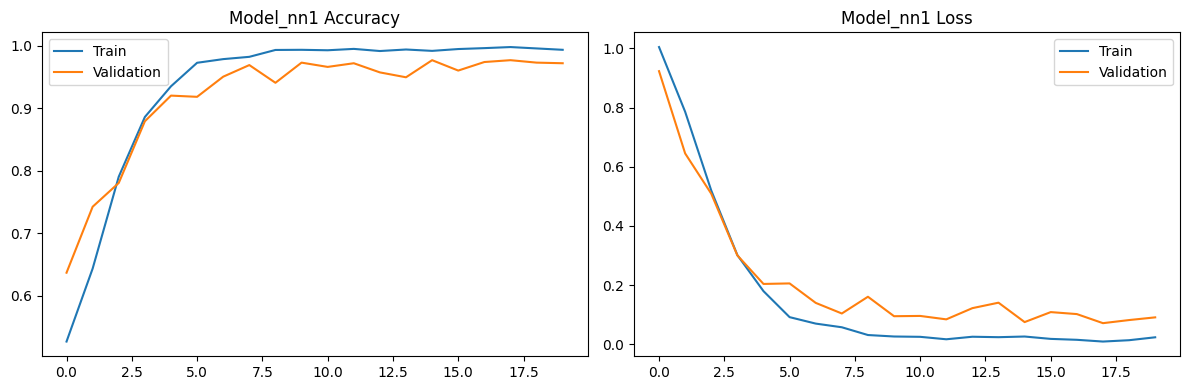

In [122]:
#Plotting model_nn1 result
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#accuracy
axes[0].plot(nn_history1.history['accuracy'],label='Train')
axes[0].plot(nn_history1.history['val_accuracy'],label='Validation')
axes[0].set_title('Model_nn1 Accuracy')
axes[0].legend()

#loss
axes[1].plot(nn_history1.history['loss'],label='Train')
axes[1].plot(nn_history1.history['val_loss'],label='Validation')
axes[1].set_title('Model_nn1 Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [123]:
#Verifying all value ranges and shapes prior to the training
print("train_aug_X shape:", train_aug_X.shape)
print("train_aug_Y shape:", train_aug_Y.shape)
print("valid_X shape:", valid_X.shape)
print("valid_Y shape:", valid_Y.shape)
print("X_train shape:", X_train.shape)
print("aug_X shape:", aug_X.shape)

#Verifying that pixel values are normalized between 0 and 1
print("\nX_train min/max:", X_train.min(),X_train.max())
print("aug_X min/max:", aug_X.min(),aug_X.max())
print("train_aug_X min/max:", train_aug_X.min(),train_aug_X.max())

train_aug_X shape: (8192, 128, 128, 3)
train_aug_Y shape: (8192,)
valid_X shape: (1024, 128, 128, 1)
valid_Y shape: (1024,)
X_train shape: (4096, 128, 128, 1)
aug_X shape: (4096, 128, 128, 3)

X_train min/max: 0.0 1.0
aug_X min/max: 0.0 1.0
train_aug_X min/max: 0.0 1.0


In [124]:
#loading optimized data
aug = dataset['aug']

#testing aug images size and channel
first_aug_image = aug[0]['image']
print(f"size = {first_aug_image.size}")
print(f"channel = {first_aug_image.mode}")

size = (128, 128)
channel = RGB


In [125]:
#creating void lists for the Aug data
aug_X = []
aug_Y = []

#iterating through Aug data and turning it to grayscale
for au in aug:
    #transforming the train data's RGB to grayscale
    img = np.array(au['image'].convert('L'), 
                   dtype=np.float32)
    aug_X.append(img)
    aug_Y.append(au['label'])

#transforming into a numpy array
aug_X = np.array(aug_X)
aug_Y = np.array(aug_Y)

#normalizing from 0-255 to 0-1
aug_X = aug_X / 255.0

#adding the same channel dimension as the train data
aug_X = aug_X.reshape(aug_X.shape[0], 128, 128, 1)

#Verifying distribution and shape
print("aug_X shape:   ", aug_X.shape)
print("aug_X min/max: ", aug_X.min(), aug_X.max())
print("Aug distribution:", Counter(aug_Y.tolist()))

aug_X shape:    (4096, 128, 128, 1)
aug_X min/max:  0.0 1.0
Aug distribution: Counter({2: 2044, 3: 1430, 0: 579, 1: 43})


In [126]:
#combining train and aug data
train_aug_X = np.concatenate([X_train, aug_X])
train_aug_Y = np.concatenate([Y_train, aug_Y])

#verifying the distribution and form of combined data
print("Merged shape:", train_aug_X.shape)
print("Merged distribution:", Counter(train_aug_Y.tolist()))

#checking that the validation and train shapes match
print("\nverifying shapes:")
print("train_aug_X:", train_aug_X.shape)
print("valid_X:", valid_X.shape)
print("Last 3 dims match?",train_aug_X.shape[1:] == valid_X.shape[1:])

Merged shape: (8192, 128, 128, 1)
Merged distribution: Counter({2: 4088, 3: 2860, 0: 1158, 1: 86})

verifying shapes:
train_aug_X: (8192, 128, 128, 1)
valid_X: (1024, 128, 128, 1)
Last 3 dims match? True


In [127]:
#constructing model_nn2 for combined augmented data
model_nn2 = keras.Sequential([

    keras.Input(shape=(128, 128, 1)),

    #The first convolutional block gathers the fundamental edge characteristics
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    #The second convolutional block gathers the more complex shape features
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    #The third convolutional block identifies high-level, complicated brain properties
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    #transforming 2D feature maps to 1D
    layers.Flatten(),

    #dense layers for categorization
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # output layer
    layers.Dense(4, activation='softmax')
])

# compiling model
model_nn2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_nn2.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,514,948 (32.48 MB)

 Trainable params: 8,514,948 (32.48 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:
#integrating model_nn2 to combined enhanced data.
history3 = model_nn2.fit(
    train_aug_X, train_aug_Y,
    epochs=20,
    batch_size=32,
    validation_data=(valid_X, valid_Y),
    verbose=1
)

Epoch 1/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 49s 186ms/step - accuracy: 0.4912 - loss: 1.0468 - val_accuracy: 0.5518 - val_loss: 1.0264
Epoch 2/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 51s 199ms/step - accuracy: 0.5472 - loss: 0.9446 - val_accuracy: 0.5791 - val_loss: 0.9027
Epoch 3/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 52s 205ms/step - accuracy: 0.5632 - loss: 0.9081 - val_accuracy: 0.5967 - val_loss: 0.8472
Epoch 4/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 53s 208ms/step - accuracy: 0.5698 - loss: 0.8911 - val_accuracy: 0.5918 - val_loss: 0.8780
Epoch 5/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 59s 232ms/step - accuracy: 0.5903 - loss: 0.8562 - val_accuracy: 0.6387 - val_loss: 0.7603
Epoch 6/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 57s 223ms/step - accuracy: 0.6067 - loss: 0.8280 - val_accuracy: 0.6562 - val_loss: 0.7191
Epoch 7/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 57s 222ms/step - accuracy: 0.6309 - loss: 0.7855 - val_accuracy: 0.7168 - val_loss: 0.6435
Epoch 8/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 55s 215ms/step - accuracy: 0.6490 - loss: 0

In [129]:
#predicting from validation data using model_nn2
valid_predict3 = np.argmax(model_nn2.predict(valid_X), axis=1)

print("Accuracy:",accuracy_score(valid_Y, valid_predict3))
print(classification_report(valid_Y, valid_predict3,target_names=classes_names))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Accuracy: 0.9443359375
                    precision    recall  f1-score   support

     Mild Demented       0.96      0.87      0.91       145
 Moderate Demented       1.00      0.67      0.80         6
      Non Demented       0.96      0.96      0.96       522
Very Mild Demented       0.91      0.95      0.93       351

          accuracy                           0.94      1024
         macro avg       0.96      0.86      0.90      1024
      weighted avg       0.95      0.94      0.94      1024



In [ ]:
#plotting model 3 result

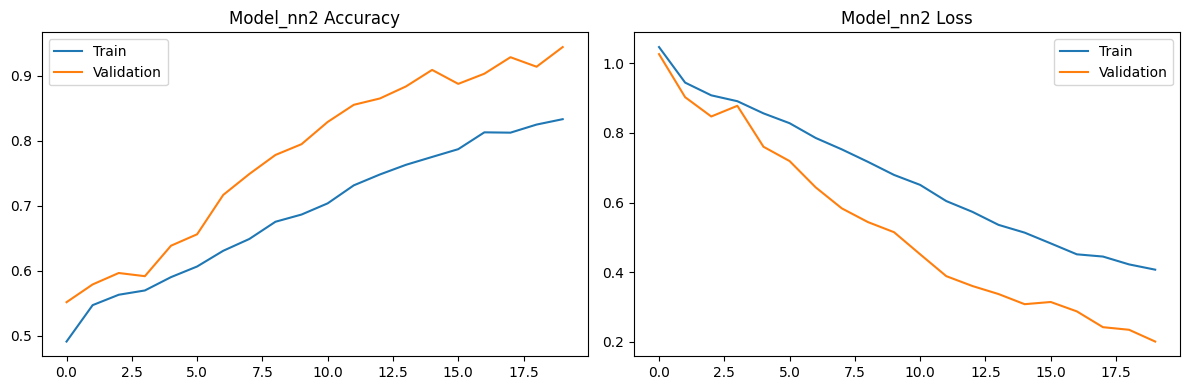

In [130]:
# plotting model_nn2 result
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# accuracy
axes[0].plot(history3.history['accuracy'],label='Train')
axes[0].plot(history3.history['val_accuracy'],label='Validation')
axes[0].set_title('Model_nn2 Accuracy')
axes[0].legend()

# loss
axes[1].plot(history3.history['loss'],label='Train')
axes[1].plot(history3.history['val_loss'],label='Validation')
axes[1].set_title('Model_nn2 Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#Prepare test data

In [131]:
#collecting test data
test_data = dataset['test']

#generating empty listings
testdata_X = []
testdata_Y = []

#looping over test data and attaching images and labels
for i in test_data:
    img = np.array(i['image'], dtype=np.float32)
    testdata_X.append(img)
    testdata_Y.append(i['label'])

#converting to numpy array
testdata_X = np.array(testdata_X)
testdata_Y = np.array(testdata_Y)

#normalizing from 0-255 to 0-1
testdata_X = testdata_X / 255.0

#converting to grayscale
if len(testdata_X.shape) == 4:testdata_X = testdata_X.mean(axis=-1)

#adding channel dimension
testdata_X = testdata_X.reshape(testdata_X.shape[0],128,128,1)

print("testdata_X shape:", testdata_X.shape)
print("testdata_Y shape:", testdata_Y.shape)

testdata_X shape: (1280, 128, 128, 1)
testdata_Y shape: (1280,)


In [ ]:
#Test model_nn1

In [132]:
# testing model_nn1 on test data
test_pred1 = np.argmax(model_nn1.predict(testdata_X), axis=1)

#printing accuracy and reports
print("Model_nn1 on test data")
print("Accuracy:", accuracy_score(testdata_Y, test_pred1))
print(classification_report(testdata_Y, test_pred1,target_names=classes_names))

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Model_nn1 on test data
Accuracy: 0.9625
                    precision    recall  f1-score   support

     Mild Demented       0.96      0.95      0.96       172
 Moderate Demented       1.00      0.93      0.97        15
      Non Demented       0.95      0.98      0.97       634
Very Mild Demented       0.98      0.94      0.96       459

          accuracy                           0.96      1280
         macro avg       0.97      0.95      0.96      1280
      weighted avg       0.96      0.96      0.96      1280



In [ ]:
#Test model_nn2

In [133]:
# testing model_nn2 on test data
test_pred2 = np.argmax(model_nn2.predict(testdata_X), axis=1)

#printing accuracy and reports
print("Model_nn2 on test data")
print("Accuracy:", accuracy_score(testdata_Y, test_pred2))
print(classification_report(testdata_Y, test_pred2,target_names=classes_names))

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
Model_nn2 on test data
Accuracy: 0.940625
                    precision    recall  f1-score   support

     Mild Demented       0.98      0.86      0.92       172
 Moderate Demented       1.00      0.80      0.89        15
      Non Demented       0.96      0.96      0.96       634
Very Mild Demented       0.91      0.94      0.92       459

          accuracy                           0.94      1280
         macro avg       0.96      0.89      0.92      1280
      weighted avg       0.94      0.94      0.94      1280



In [ ]:
#confusion matrxi model_nn1

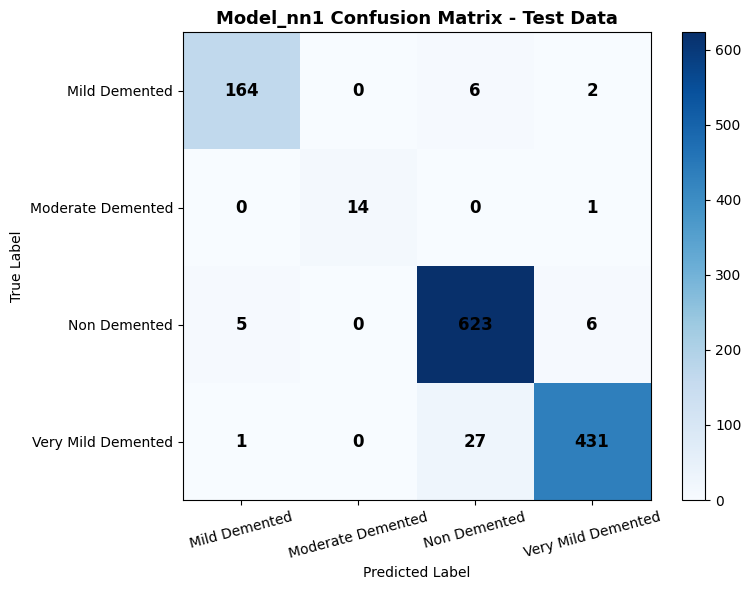

In [134]:
# importing confusion matrix
from sklearn.metrics import confusion_matrix

#computing the confusion matrix for model_nn1
con_matrix1 = confusion_matrix(testdata_Y, test_pred1)

#plotting confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(con_matrix1, cmap='Blues')

#putting class names on the x and y axes
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(classes_names, rotation=15)
ax.set_yticklabels(classes_names)

#Adding numbers into each box
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(con_matrix1[i][j]),ha='center', va='center',fontsize=12, fontweight='bold')

# adding title and labels
ax.set_title('Model_nn1 Confusion Matrix - Test Data',fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
#confusion matrix model_nn2

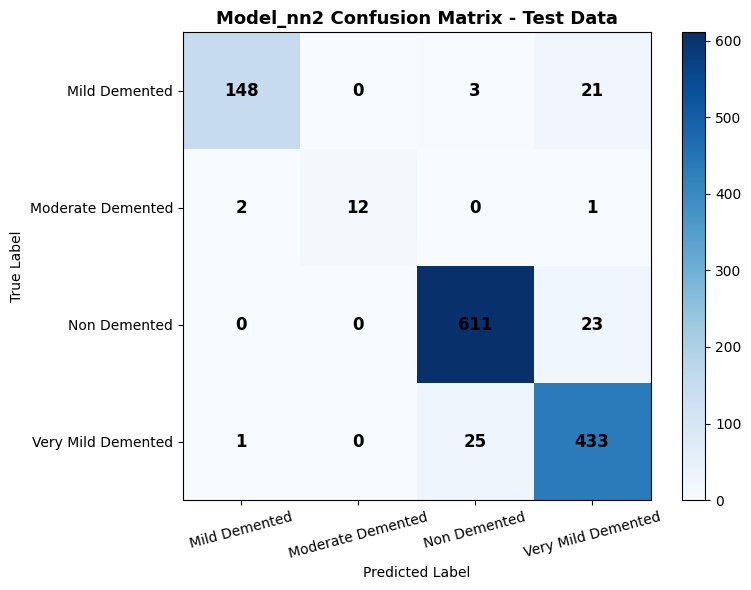

In [136]:
#computing the confusion matrix for model_nn2
con_matrix2 = confusion_matrix(testdata_Y, test_pred2)

#plotting confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(con_matrix2, cmap='Blues')

#putting class names on the x and y axes
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(classes_names, rotation=15)
ax.set_yticklabels(classes_names)

#adding numbers into each box
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(con_matrix2[i][j]),ha='center', va='center',fontsize=12, fontweight='bold')

# adding title and labels
ax.set_title('Model_nn2 Confusion Matrix - Test Data',fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
#Final Comparison Summary

In [137]:
#Print the final comparison report of both models
print("FINAL RESULTS SUMMARY")

print("\nValidation Results:")
print(f"Model_nn1 Accuracy: 96.68%")
print(f"Model_nn2 Accuracy: 94.04%")

print("\nTest Results:")
print(f"Model_nn1 Accuracy: {accuracy_score(testdata_Y, test_pred1)*100:.2f}%")
print(f"Model_nn2 Accuracy: {accuracy_score(testdata_Y, test_pred3)*100:.2f}%")

FINAL RESULTS SUMMARY

Validation Results:
Model_nn1 Accuracy: 96.68%
Model_nn2 Accuracy: 94.04%

Test Results:
Model_nn1 Accuracy: 96.25%
Model_nn2 Accuracy: 94.14%
